### Import the proper functions, and define helper functions

In [3]:
import sys, os
import matplotlib
import time
import pandas as pd
import numpy
import ast
import json
import matplotlib.pyplot as plt
matplotlib.use('Agg')
from sklearn.neighbors import KNeighborsClassifier as knnbase
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.naive_bayes import MultinomialNB as mnb
from sklearn.linear_model import LogisticRegression as LR
from sklearn.naive_bayes import GaussianNB as GNB

from autogluon.tabular import TabularDataset
from autogluon.tabular import TabularPredictor as task
from autogluon.core.utils import infer_problem_type

from sklearn.model_selection import GridSearchCV as GSCV
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler as MMS
from sklearn.preprocessing import StandardScaler as SS

from sklearn.metrics import accuracy_score, hamming_loss, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix as ML_matrix
from sklearn.metrics import precision_recall_fscore_support as score_multi
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from pickle import load, dump
from sklearn.utils import resample
from sklearn.metrics import classification_report
from scipy.stats import ttest_ind


In [4]:
# -------------------------------- HELPERS ------------------------------------------ #
def split_df(Xdata, labels, testsplit=0.3):
	Xtrain,Xtest,ytrain,ytest = train_test_split(Xdata,labels,test_size=testsplit)
	return Xtrain, Xtest, ytrain, ytest

# Rescale values to fit in a range; default: 0-1
def normalize(Xtrain, Xtest):
	scaler = MMS(feature_range=(0,1))
	Xtrainscaled = scaler.fit_transform(Xtrain)
	Xtestscaled = scaler.transform(Xtest)
	return Xtrainscaled, Xtestscaled

# Scale values such that mean = 0, std dev. = 1; Ensures robustness for new data.
def standardize(Xtrain, Xtest):
	ss = SS()
	Xtrainscaled = ss.fit_transform(Xtrain)
	Xtestscaled = ss.transform(Xtest)
	return Xtrainscaled, Xtestscaled, ss

def micro_avg(y_test_multilabel, predictions):
	precision = precision_score(y_test_multilabel, predictions, average='micro')
	recall = recall_score(y_test_multilabel, predictions, average='micro')
	f1 = f1_score(y_test_multilabel, predictions, average='micro')

	print("::Micro-average::")
	print("Precision: {:.4f}, Recall: {:.4f}, F1-measure: {:.4f}".format(precision, recall, f1))
	print("\n\n")
	return precision, recall, f1

def macro_avg(y_test_multilabel, predictions):
	precision = precision_score(y_test_multilabel, predictions, average='macro')
	recall = recall_score(y_test_multilabel, predictions, average='macro')
	f1 = f1_score(y_test_multilabel, predictions, average='macro')

	print("\nMacro-average: ")
	print("Precision: {:.4f}, Recall: {:.4f}, F1-measure: {:.4f}".format(precision, recall, f1))
	return

def per_class_dist(ytest, ypred, classorder):
	perclass = classification_report(ytest, ypred)
	print("Per class classification report: ", perclass)
	precision, recall, fscore, support = score_multi(ytest, ypred, average="micro")
	print('micro-precision: {}'.format(precision))
	print('micro-recall: {}'.format(recall))
	print('micro-fscore: {}'.format(fscore))
	print('support: {}'.format(support))
	#print(classorder)
	return

def output_avg(total, ag_res1, ag_res2, fimp1, fimp2, auto_cmatrix, perf, auc_score, ff):
	print(auto_cmatrix)
	ff.write("-----------------Autogluon----------------\n")
	ff.write("Best model confusion matrix: \n")
	[tn,fp,fn,tp] = auto_cmatrix
	fpr = float(fp/(fp+tn)*100)
	ff.write("TN: "+str(tn)+" FP: "+str(fp)+" FN: "+str(fn)+" TP: "+str(tp)+"\n")
	ff.write("::Model performance on test data::\n")
	ff.write("AUC Score: "+str(auc_score)+"\n")
	ff.write("FPR: "+str(fpr)+"\n")
	ff.write("Performance summary: "+str(perf)+" \n")
	ff.write(str(ag_res1))
	if not fimp1 == None:
		ff.write("*Ft impo*\n")
		ff.write(str(fimp1.head(20))+"\n")
	ff.write("\n::Stacking & Weighted Ensembling of Models::\n")
	ff.write(str(ag_res2))
	if not fimp2 == None:
		ff.write("*Ft impo*\n")
		ff.write(str(fimp2.head(20))+"\n")
	ff.write("--------------------------------------------\n")
	ff.close()
	return

In [5]:
def test_main(xtest, ytest, pred, testdf, traindf, calcftimpo=False):
	modelperf = pred.leaderboard(testdf, silent= True)
	print("[*]Model performance breakdown on Test data:")
	print(modelperf)
	ypred = pred.predict(xtest)
	ypredproba = pred.predict_proba(xtest)
	perf = pred.evaluate_predictions(y_true=ytest, y_pred=ypred, auxiliary_metrics= True)
	print("[*]Predictions: ", ypred)
	print("[*]Confidence in predictions:\n")
	print(pd.DataFrame(ypredproba, columns=pred.class_labels))
	# Each model score
	print("Perf: ", perf)
	print(classification_report(y_test, ypred, output_dict=True))

	print("Getting confusion matrix.....")
	cmatrix = confusion_matrix(ytest, ypred).ravel().tolist()
	print(cmatrix)
	auc_score = roc_auc_score(ytest, ypredproba.iloc[:, 1])
	print("AUC score for best model: ", auc_score)

	if calcftimpo:
		ftimpo = None
		ftimpo = pred.feature_importance(traindf)
		print("Feature Importance on test data: ", ftimpo)
	else:
		ftimpo = None
	bestmodel = pred.model_best
	# Find mistakes
	misclassified = xtest[ypred != ytest].copy()
	misclassified['true_label'] = ytest[ypred != ytest]
	misclassified['predicted_label'] = ypred[ypred != ytest]
	return modelperf, ftimpo, cmatrix, ypredproba, bestmodel, perf, auc_score, misclassified

def test_stack(xtest, ytest, predstack, testdf, traindf, calcftimpo=False):
	ypred = predstack.predict(xtest)
	ypredproba = predstack.predict_proba(xtest)
	perf = predstack.evaluate_predictions(y_true=ytest, y_pred=ypred, auxiliary_metrics= True)
	print("[*]Predictions: ", ypred)
	test_perf = predstack.leaderboard(testdf, silent=True)
	print("$$$$$$$$ RESULT STACKING $$$$$$$$\n", test_perf)
	ftimpo = None
	if calcftimpo:
		ftimpo = predstack.feature_importance(traindf)
		print("Feature Importance on test data: ", ftimpo)
	auc_score = roc_auc_score(ytest, ypredproba.iloc[:, 1])
	cmatrix = confusion_matrix(ytest, ypred).ravel().tolist()
	print("Confusion matrix stacked: ", cmatrix)
	print("AUC using stacked model: ", auc_score)
	return test_perf, ftimpo, cmatrix, auc_score

In [4]:
ag_args_fit = {'num_gpus': 1}  # Allocate 1 GPU
    
def train_main(data_df, val_df, target_col, presets='medium_quality'):
	agdir = os.getcwd()+'/AGmodels/'
	if not os.path.exists(agdir):
		os.system("mkdir "+agdir)

	if presets == 'medium_quality':
		predictor = task(label=target_col, path=agdir, eval_metric='f1').fit(train_data=data_df, tuning_data=val_df, verbosity=3, ag_args_fit=ag_args_fit, presets='medium_quality')
	else:
		all_data = pd.concat([data_df, val_df])
		predictor = task(label=target_col, path=agdir, eval_metric='f1').fit(train_data=all_data, verbosity=3, ag_args_fit=ag_args_fit, presets='best_quality')
     
	return predictor

# Multi layer stacking takes predictions of base models and feeds to stack models
# AG will auto choose k= 10 fold cv, n=20 bagging repeats,
# L: 2 layers of models in stack followed by weighted-ensemble (higher weight for the model that performed well);
# Aggregate model predictions based on model weights and produce final prediction
def train_multilayerstacking(traindf, target):
	agdir_stack = os.getcwd()+'/AGmodels/stacked/' #+str(malinst)+"_"+str(hostfts)+"/"
	if not os.path.exists(agdir_stack):
		os.system("mkdir "+agdir_stack)
	predstack = task(label=target, path=agdir_stack, eval_metric='f1').fit(train_data= traindf, auto_stack=True, verbosity=3)
	return predstack


In [61]:
rel_test = rel_test_rtt.merge(rel_test_up, on=['pcap_nb', 'conn'])
rel_train = rel_train_rtt.merge(rel_train_up, on=['pcap_nb', 'conn'])
rel_val = rel_val_rtt.merge(rel_val_up, on=['pcap_nb', 'conn'])

bg_test = bg_test_rtt.merge(bg_test_up, on=['pcap_nb', 'conn'])
bg_train = bg_train_rtt.merge(bg_train_up, on=['pcap_nb', 'conn'])
bg_val = bg_val_rtt.merge(bg_val_up, on=['pcap_nb', 'conn'])

rel_test['label'] = 1
rel_train['label'] = 1
rel_val['label'] = 1

bg_test['label'] = 0
bg_train['label'] = 0
bg_val['label'] = 0

test_df = pd.concat([rel_test, bg_test])
train_df = pd.concat([rel_train, bg_train])
val_df = pd.concat([rel_val, bg_val])

test_df.drop(columns=['conn', 'pcap_nb'], inplace=True)
train_df.drop(columns=['conn', 'pcap_nb'], inplace=True)
val_df.drop(columns=['conn', 'pcap_nb'], inplace=True)

In [26]:
train_df = pd.read_csv("../content/subset_features_03_18/train/all_features.csv")
test_df = pd.read_csv("../content/subset_features_03_18/test/all_features.csv")
val_df = pd.read_csv("../content/subset_features_03_18/val/all_features.csv")

In [31]:
print(len(test_df[test_df['label'] == 1]))
test_corr_df = pd.read_csv("../content/subset_features_03_18/test/corr_feature_50.csv") 
print(len(test_corr_df[test_corr_df['label'] == 1]))

1110
2317


In [14]:
train_corr_df = pd.read_csv("../content/subset_features_03_18/train/first_3_corr_feature_50.csv")
test_corr_df = pd.read_csv("../content/subset_features_03_18/test/first_3_corr_feature_50.csv")
val_corr_df = pd.read_csv("../content/subset_features_03_18/val/first_3_corr_feature_50.csv")

In [24]:
test_df = test_corr_df.drop(columns=['conn', 'pcap_nb'], axis=1)
train_df = train_corr_df.drop(columns=['conn', 'pcap_nb'], axis=1)
val_df = val_corr_df.drop(columns=['conn', 'pcap_nb'], axis=1)

In [88]:


# Use to decide which experiment to run
def run_experiment_setting(test_df, train_df, val_df, experiment_number):
    if experiment_number == 0:
        None
    elif experiment_number == 1:
        # Setting where we only look at correlation features
        corr_features = ['corr_mean', 'corr_sum', 'corr_maximum', 'corr_variance', 'label']
        test_df = test_df[corr_features]
        train_df = train_df[corr_features]
        val_df = val_df[corr_features]
    elif experiment_number == 2:
        # Setting where correlation is not considered
        test_df = test_df.drop(test_df.filter(like="corr").columns, axis=1)
        train_df = train_df.drop(train_df.filter(like="corr").columns, axis=1)
        val_df = val_df.drop(val_df.filter(like="corr").columns, axis=1)
    elif experiment_number == 3:
        # Setting where only RTT feature is considered
        rtt_feature = ['rtt', 'label']
        test_df = test_df[rtt_feature]
        train_df = train_df[rtt_feature]
        val_df = val_df[rtt_feature]
    elif experiment_number == 4:
        # Setting where RTT feature is dropped
        rtt_feature = ['rtt', 'label']
        # Setting where correlation is not considered
        test_df = test_df.drop(columns=['rtt'], axis=1)
        train_df = train_df.drop(columns=['rtt'], axis=1)
        val_df = val_df.drop(columns=['rtt'], axis=1)
        
    return test_df, train_df, val_df

test_df, train_df, val_df = run_experiment_setting(test_df, train_df, val_df, 0)
    

In [25]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import xgboost as xgb
from math import sqrt

# Assuming val_df is already loaded
# Process validation data similarly to train and test
X_val = val_df.drop(columns=['label']).reset_index(drop=True)
y_val = val_df['label']

# Prepare training data
train_df = train_df.sample(frac=1).reset_index(drop=True)
train_df = train_df.astype(float)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

# Prepare test data
X_test = test_df.drop(columns=['label']).reset_index(drop=True)
y_test = test_df['label']

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
)

# Train the model with early stopping using validation data
xgb_model.fit(
    X_train, y_train,
    verbose=True,  # Print evaluation results
    eval_set=[(X_val, y_val)]
)

# Make predictions on test set
y_pred = xgb_model.predict(X_test)
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix for test set
cf = confusion_matrix(y_test, y_pred)
print(cf)
TN = cf[0][0]
FP = cf[0][1]
print("FPR (%): ", FP/(TN + FP) * 100)

[0]	validation_0-logloss:0.15572
[1]	validation_0-logloss:0.14134
[2]	validation_0-logloss:0.12928
[3]	validation_0-logloss:0.11856
[4]	validation_0-logloss:0.10864
[5]	validation_0-logloss:0.10001
[6]	validation_0-logloss:0.09282
[7]	validation_0-logloss:0.08598
[8]	validation_0-logloss:0.07982
[9]	validation_0-logloss:0.07451
[10]	validation_0-logloss:0.06955
[11]	validation_0-logloss:0.06520
[12]	validation_0-logloss:0.06138
[13]	validation_0-logloss:0.05793
[14]	validation_0-logloss:0.05467
[15]	validation_0-logloss:0.05183
[16]	validation_0-logloss:0.04924
[17]	validation_0-logloss:0.04706
[18]	validation_0-logloss:0.04503
[19]	validation_0-logloss:0.04325
[20]	validation_0-logloss:0.04175
[21]	validation_0-logloss:0.04036
[22]	validation_0-logloss:0.03897
[23]	validation_0-logloss:0.03762
[24]	validation_0-logloss:0.03653
[25]	validation_0-logloss:0.03567
[26]	validation_0-logloss:0.03497
[27]	validation_0-logloss:0.03436
[28]	validation_0-logloss:0.03358
[29]	validation_0-loglos

In [23]:
%matplotlib inline


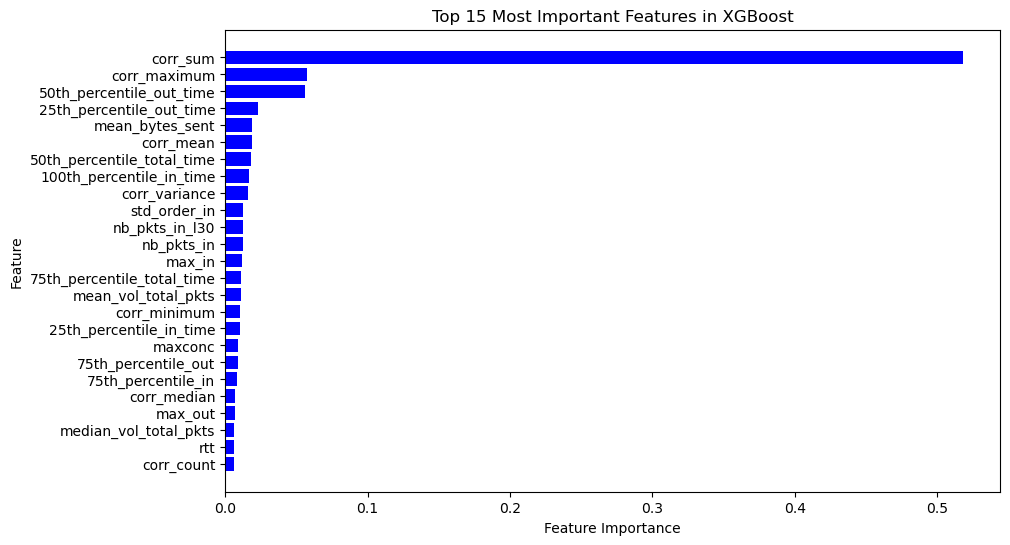

In [47]:
# Get feature importances
importances = xgb_model.feature_importances_

# Create a DataFrame for better sorting
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select the top 15 features
top_features = feature_importance_df.head(25)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="blue")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features in XGBoost")
plt.gca().invert_yaxis()  # Invert to show the most important on top
plt.show()


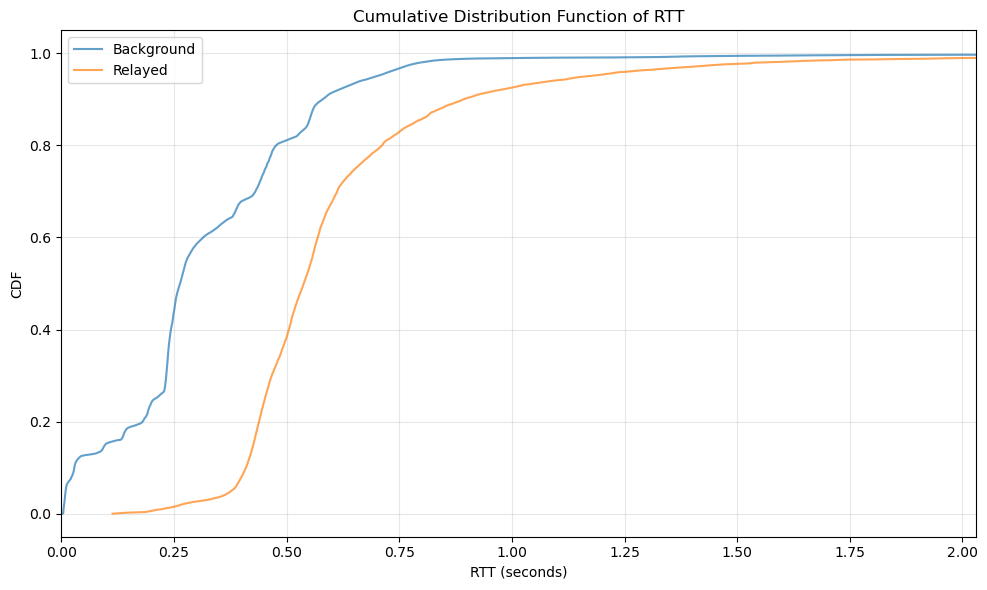

In [43]:
import numpy as np

import matplotlib.pyplot as plt

# Sort values for CDF calculation
bg_sorted = np.sort(bg['rtt'])
rel_sorted = np.sort(rel['rtt'])

# Calculate CDF values 
bg_cdf = np.arange(1, len(bg_sorted) + 1) / len(bg_sorted)
rel_cdf = np.arange(1, len(rel_sorted) + 1) / len(rel_sorted)

# Create CDF plot
plt.figure(figsize=(10, 6))
plt.plot(bg_sorted, bg_cdf, label='Background', alpha=0.7)
plt.plot(rel_sorted, rel_cdf, label='Relayed', alpha=0.7)

plt.xlabel('RTT (seconds)')
plt.ylabel('CDF')
plt.title('Cumulative Distribution Function of RTT')
plt.grid(True, alpha=0.3)
plt.legend()

# Set reasonable x-axis limits based on data
plt.xlim(left=0)
percentile_99 = max(np.percentile(bg_sorted, 99), np.percentile(rel_sorted, 99))
plt.xlim(right=percentile_99)

plt.tight_layout()

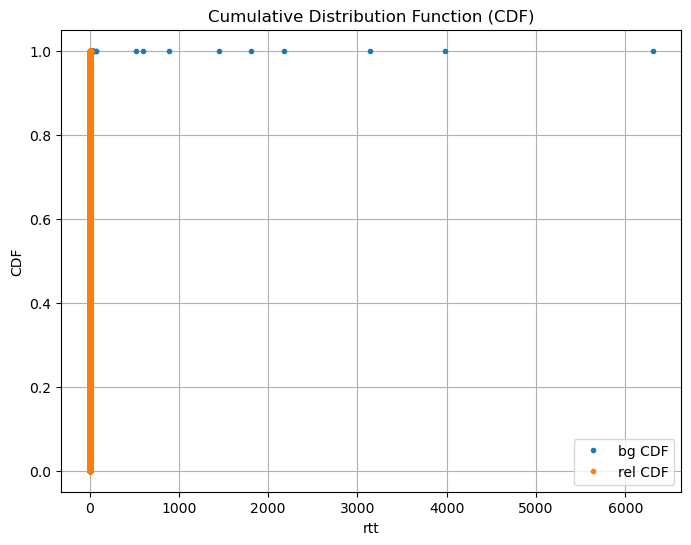

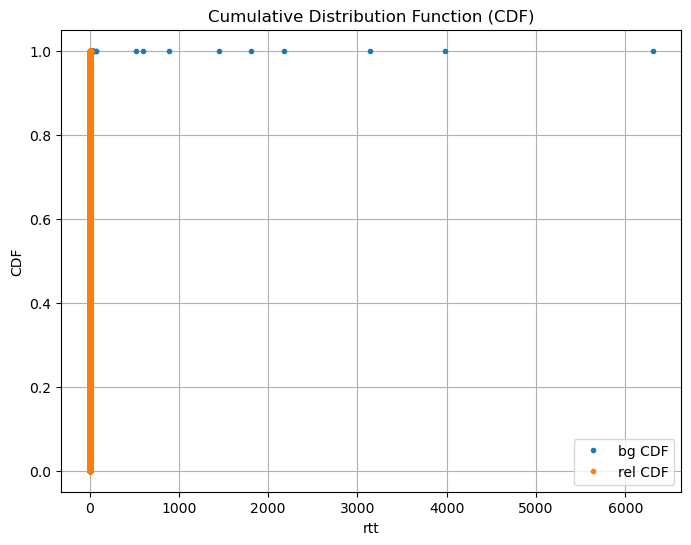

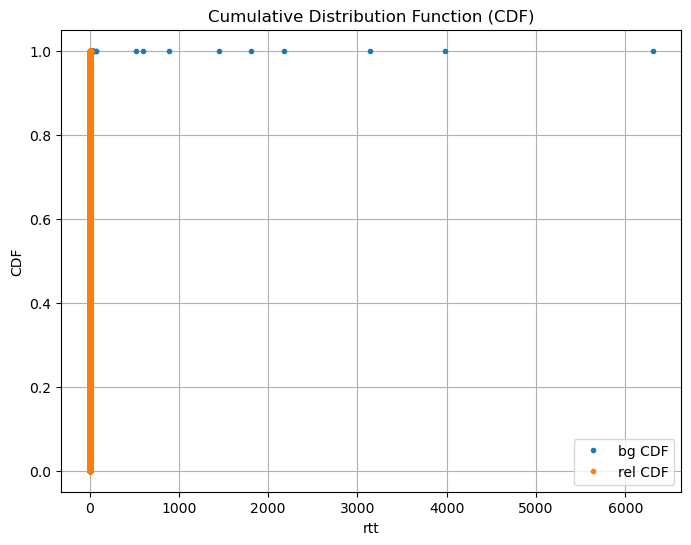

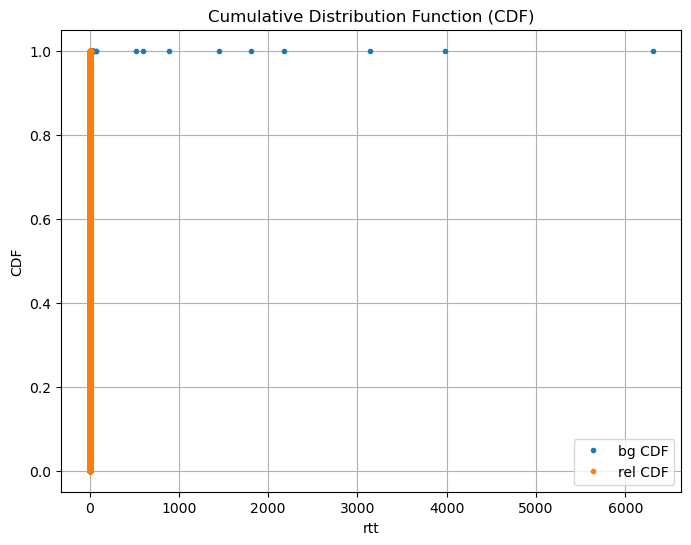

In [38]:
import numpy as np

# Example: Assuming the column of interest is 'values'
column_name = 'rtt'

# Compute CDF for bg DataFrame
bg_sorted = np.sort(bg[column_name])
bg_cdf = np.arange(1, len(bg_sorted) + 1) / len(bg_sorted)

# Compute CDF for rel DataFrame
rel_sorted = np.sort(rel[column_name])
rel_cdf = np.arange(1, len(rel_sorted) + 1) / len(rel_sorted)

# Plot CDFs
plt.figure(figsize=(8, 6))
plt.plot(bg_sorted, bg_cdf, label='bg CDF', marker='.', linestyle='none')
plt.plot(rel_sorted, rel_cdf, label='rel CDF', marker='.', linestyle='none')

plt.xlabel(column_name)
plt.ylabel("CDF")
plt.title("Cumulative Distribution Function (CDF)")
plt.legend()
plt.grid()

display(plt.gcf())  # Use this to display the plot in Jupyter


In [25]:
def process_df(df, background=True):
    # Add proper label
    df['label'] = 0 if background else 1
    
    # Remove unnecessary columns
    # columns_to_drop = ['mean_vol_total_pkts', 'conn', 'pcap_nb', 'mean_bytes_sent', 'mean_bytes_recv']
    # df.drop(columns = columns_to_drop, inplace=True)
    
    # Temporary change TODO: change later. To see affect of RTT
    columns_to_kepp = ['rtt', 'label']
    columns_to_drop = [column for column in df.columns if column not in columns_to_kepp]
    return df.drop(columns=columns_to_drop, inplace=True)
    


def process_rel_df(df):
    return process_df(df, False)

def process_bg_df(df):
    return process_df(df, True)

In [26]:
RANDOM_STATE = 42
#------------------------------------------------------------------------------
# Process pcaps: add labels and remove unnecessary columns
#------------------------------------------------------------------------------
for rel_df in [rel_train, rel_val, rel_test]:
    process_rel_df(rel_df)
    
for bg_df in [bg_train, bg_val, bg_test]:
    process_bg_df(bg_df)
    

# Combine relayed and background datasets
train = pd.concat([rel_train, bg_train], ignore_index=True)
val = pd.concat([rel_val, bg_val], ignore_index=True)
test = pd.concat([rel_test, bg_test], ignore_index=True)


# Remove all columns with 0 std dev
# std_devs = train.std()
# features_to_keep = std_devs[std_devs != 0].index
# train = train[features_to_keep]
# val = val[features_to_keep]
# test = test[features_to_keep]

# Print shapes to verify splits
print(f"Training set shape: {train.shape}")
print(f"Validation set shape: {val.shape}")
print(f"Test set shape: {test.shape}")

#------------------------------------------------------------------------------
# Balance the training dataset
#------------------------------------------------------------------------------
# Separate majority and minority classes
majority_class = train[train['label'] == 0]
minority_class = train[train['label'] == 1]



# Downsample majority class to reduce class imbalance (6:1 ratio)
desired_majority_size = int(len(minority_class) * 6)
majority_downsampled = resample(majority_class,
                              replace=False,
                              n_samples=desired_majority_size,
                              random_state=RANDOM_STATE)

# Print dataset shapes for verification

print("Training set shape:", majority_downsampled.shape[0] + minority_class.shape[0])
print("Test set shape:", test.shape[0])
print("Validation set shape:", val.shape[0])

# Create final balanced training dataset
train_balanced = pd.concat([majority_downsampled, minority_class])
train_balanced = train_balanced.dropna()

Training set shape: (686421, 2)
Validation set shape: (198992, 2)
Test set shape: (204698, 2)
Training set shape: 82369
Test set shape: 204698
Validation set shape: 198992


In [28]:
# Training binary classifiers: 8 base models, 2 DL models
predictor = train_main(train_balanced,val, "label", "medium_quality")

Verbosity: 3 (Detailed Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.16
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Fri Jan 24 04:59:58 UTC 2025
CPU Count:          32
GPU Count:          1
Memory Avail:       41.03 GB / 62.50 GB (65.6%)
Disk Space Avail:   1324.09 GB / 1906.14 GB (69.5%)
Presets specified: ['medium_quality']
============ fit kwarg info ============
User Specified kwargs:
{'ag_args_fit': {'num_gpus': 1}, 'auto_stack': False, 'verbosity': 3}
Full kwargs:
{'_feature_generator_kwargs': None,
 '_save_bag_folds': None,
 'ag_args': None,
 'ag_args_ensemble': None,
 'ag_args_fit': {'num_gpus': 1},
 'auto_stack': False,
 'calibrate': 'auto',
 'delay_bag_sets': False,
 'ds_args': {'clean_up_fits': True,
             'detection_time_frac': 0.25,
             'enable_callbacks': False,
             'enable_ray_logging': True,
             'holdout_data': None,
     

[50]	valid_set's binary_logloss: 0.155117	valid_set's f1: 0.180346
[100]	valid_set's binary_logloss: 0.153977	valid_set's f1: 0.205123


Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/LightGBM/y_pred_proba_val.pkl
	0.2051	 = Validation score   (f1)
	5.44s	 = Training   runtime
	0.03s	 = Validation runtime
	6689586.4	 = Inference  throughput (rows/s | 198992 batch size)
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/trainer.pkl
Fitting model: RandomForestGini ...
	Fitting RandomForestGini with 'num_gpus': 1, 'num_cpus': 32
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestGini/model.pkl
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/RandomForestGini/y_pred_proba_val.pkl
	0.1222	 = Validation score   (f1)
	1.46s	 = Training   runtime
	0.26s	 = Validation runtime
	765373.5	 = Inference  throughput (rows/s | 198992 batch size)
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/trainer.pkl
Fitting model: RandomF

0:	learn: 0.6299016	test: 0.6185314	best: 0.6185314 (0)	total: 4.75ms	remaining: 47.5s
20:	learn: 0.3181858	test: 0.2150692	best: 0.2150692 (20)	total: 48.3ms	remaining: 22.9s
40:	learn: 0.2939740	test: 0.1696121	best: 0.1696121 (40)	total: 92.4ms	remaining: 22.5s
60:	learn: 0.2898907	test: 0.1596452	best: 0.1596452 (60)	total: 136ms	remaining: 22.2s
80:	learn: 0.2882006	test: 0.1565080	best: 0.1565080 (80)	total: 179ms	remaining: 21.9s
100:	learn: 0.2876654	test: 0.1557105	best: 0.1557105 (100)	total: 222ms	remaining: 21.8s
120:	learn: 0.2872329	test: 0.1553133	best: 0.1553133 (120)	total: 265ms	remaining: 21.6s
140:	learn: 0.2870412	test: 0.1552336	best: 0.1552336 (140)	total: 304ms	remaining: 21.2s
160:	learn: 0.2869295	test: 0.1551812	best: 0.1551761 (156)	total: 343ms	remaining: 21s
180:	learn: 0.2867362	test: 0.1550982	best: 0.1550871 (164)	total: 382ms	remaining: 20.7s


Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/CatBoost/y_pred_proba_val.pkl
	0.2008	 = Validation score   (f1)
	0.79s	 = Training   runtime
	0.01s	 = Validation runtime
	30806220.9	 = Inference  throughput (rows/s | 198992 batch size)
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/trainer.pkl
Fitting model: ExtraTreesGini ...
	Fitting ExtraTreesGini with 'num_gpus': 1, 'num_cpus': 32


...

/home/temoorali/.conda/envs/traffic_training/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:01:22] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/home/temoorali/.conda/envs/traffic_training/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:01:22] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
Saving /home/temoorali/Documents/ProxyTr

[50]	valid_set's binary_logloss: 0.157751	valid_set's f1: 0.144813
[100]	valid_set's binary_logloss: 0.154465	valid_set's f1: 0.196278
[150]	valid_set's binary_logloss: 0.154015	valid_set's f1: 0.199152


[LightGBM] [Fatal] Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 846 .



[50]	valid_set's binary_logloss: 0.157751	valid_set's f1: 0.144813
[100]	valid_set's binary_logloss: 0.154464	valid_set's f1: 0.196278
[150]	valid_set's binary_logloss: 0.154015	valid_set's f1: 0.199152
[200]	valid_set's binary_logloss: 0.153947	valid_set's f1: 0.205123


Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/LightGBMLarge/y_pred_proba_val.pkl
	0.2051	 = Validation score   (f1)
	19.49s	 = Training   runtime
	0.09s	 = Validation runtime
	2193383.7	 = Inference  throughput (rows/s | 198992 batch size)
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/trainer.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/ExtraTreesEntr/y_pred_proba_val.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/NeuralNetFastAI/y_pred_proba_val.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/LightGBMLarge/y_pred_proba_val.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/RandomForestGini/y_pred_proba_val.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/utils/attr/KNeighborsDist/y_pred_proba_va

In [31]:
def keep_n_rows(df, n, random_state=42):
    return df.drop(df.sample(n=len(df) - n, random_state=random_state).index)

positive_rows = test[test['label'] == 1]
negative_rows = test[test['label'] == 0]

In [32]:
len(positive_rows)

5036

In [29]:
# Only keep percentage amount of rows in positive class

# Ensure order of columns in test frame is same as train one
test = test[train.columns]

x_test = test.drop(columns=['label'])
y_test = test['label']
# Uncomment for test results with feature importance (longer run time)
# res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = test_main(x_test, y_test, predictor, test, train,True)
res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes =test_main(x_test, y_test, predictor, test, train,True)

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsUnif/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsDist/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMXT/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestGini/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestEntr/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/ExtraTreesGini/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/ExtraTreesEntr/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetFastAI/model.pkl
Loading: /home/temoorali/Documents/ProxyT

[*]Model performance breakdown on Test data:
                  model  score_test  score_val eval_metric  pred_time_test  \
0              LightGBM    0.223732   0.205123          f1        0.026014   
1         LightGBMLarge    0.223128   0.205123          f1        0.094272   
2   WeightedEnsemble_L2    0.221504   0.205971          f1        0.290574   
3        NeuralNetTorch    0.218383   0.200456          f1        0.113343   
4              CatBoost    0.214978   0.200831          f1        0.024112   
5               XGBoost    0.214395   0.199832          f1        0.017599   
6        KNeighborsUnif    0.165913   0.155597          f1        0.219017   
7        ExtraTreesGini    0.146993   0.138154          f1        0.484060   
8        ExtraTreesEntr    0.145584   0.136776          f1        0.540507   
9        KNeighborsDist    0.142673   0.134592          f1        0.243627   
10     RandomForestEntr    0.132379   0.122243          f1        0.418126   
11     RandomForest

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsUnif/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Skipping roc_auc because no prediction probabilities are available to score.
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Computing feature importance via permutation shuffling for 1 featur

[*]Predictions:  0         1
1         0
2         0
3         0
4         0
         ..
204693    0
204694    0
204695    0
204696    0
204697    0
Name: label, Length: 204698, dtype: int64
[*]Confidence in predictions:

               0         1
0       0.371604  0.628396
1       0.610822  0.389178
2       0.686598  0.313402
3       0.621676  0.378324
4       0.701152  0.298848
...          ...       ...
204693  0.981988  0.018012
204694  0.690041  0.309959
204695  0.980434  0.019566
204696  0.991663  0.008337
204697  0.996826  0.003174

[204698 rows x 2 columns]
Perf:  {'f1': 0.22150438394093216, 'accuracy': 0.9587929535217735, 'balanced_accuracy': 0.607625212661821, 'mcc': 0.20097485932429598, 'precision': 0.20693222969477496, 'recall': 0.23828435266084194}
{'0': {'precision': 0.9807138296321248, 'recall': 0.9769660726628001, 'f1-score': 0.9788363638188383, 'support': 199662.0}, '1': {'precision': 0.20693222969477496, 'recall': 0.23828435266084194, 'f1-score': 0.22150438394093216,

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsUnif/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsUnif/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AG

Feature Importance on test data:       importance    stddev   p_value  n  p99_high   p99_low
rtt    0.156421  0.045286  0.000757  5  0.249665  0.063176


In [33]:
percentages = [0.025, 0.01, 0.007, 0.005, 0.002, 0.001]
negative_rows_len = len(negative_rows)
results_list = []

for percentage in percentages:
    # Only keep percentage amount of rows in positive class
    n_rows_to_keep = round(negative_rows_len * percentage)
    positive_rows_subset = keep_n_rows(positive_rows, n_rows_to_keep, RANDOM_STATE)
    test_subset = pd.concat([positive_rows_subset, negative_rows])
    
    # Ensure order of columns in test frame is same as train one
    test_subset = test_subset[train.columns]

    x_test = test_subset.drop(columns=['label'])
    y_test = test_subset['label']
    print(f"###################~Testing Trained Models: {percentage * 100}% with {len(positive_rows_subset)} rows" + "############################")
    # Uncomment for test results with feature importance (longer run time)
    # res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = test_main(x_test, y_test, predictor, test, train,True)
    results_list.append(test_main(x_test, y_test, predictor, test, train,True))

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsUnif/model.pkl


###################~Testing Trained Models: 2.5% with 4992 rows############################


Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsDist/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMXT/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestGini/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestEntr/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/ExtraTreesGini/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/ExtraTreesEntr/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetFastAI/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetFastAI/model-internals.pkl
Loading: /home/temoorali/Docum

[*]Model performance breakdown on Test data:
                  model  score_test  score_val eval_metric  pred_time_test  \
0   WeightedEnsemble_L2    0.977024   0.971396          f1        2.112544   
1              CatBoost    0.971123   0.963781          f1        0.039907   
2               XGBoost    0.970445   0.963916          f1        0.851519   
3        NeuralNetTorch    0.969157   0.961746          f1        1.153754   
4         LightGBMLarge    0.947263   0.941623          f1        0.061177   
5      RandomForestEntr    0.946200   0.935624          f1        0.251390   
6       NeuralNetFastAI    0.945336   0.935629          f1        1.111565   
7      RandomForestGini    0.945015   0.936289          f1        0.262012   
8              LightGBM    0.939217   0.929954          f1        0.052945   
9        ExtraTreesEntr    0.935033   0.923901          f1        0.311911   
10       ExtraTreesGini    0.934968   0.921981          f1        0.318165   
11           LightG

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Skipping roc_auc because no prediction probabilities are available to score.
These features in provided data are not utilized by the predictor and will be ignored: ['med_per_sec', 'alt_per_sec_9', 'alt_per_sec_10', 'alt_per_sec_12', 'alt_per_sec_13', 'alt_per_sec_14', 'alt_per_sec_15', 'alt_per_sec_18', 'alt_per_sec_19', 'conc_2',

...

[*]Model performance breakdown on Test data:
                  model  score_test  score_val eval_metric  pred_time_test  \
0   WeightedEnsemble_L2    0.977024   0.971396          f1        2.180699   
1              CatBoost    0.971123   0.963781          f1        0.044913   
2               XGBoost    0.970445   0.963916          f1        0.928025   
3        NeuralNetTorch    0.969157   0.961746          f1        1.138864   
4         LightGBMLarge    0.947263   0.941623          f1        0.061775   
5      RandomForestEntr    0.946200   0.935624          f1        0.252248   
6       NeuralNetFastAI    0.945336   0.935629          f1        1.645452   
7      RandomForestGini    0.945015   0.936289          f1        0.262424   
8              LightGBM    0.939217   0.929954          f1        0.048343   
9        ExtraTreesEntr    0.935033   0.923901          f1        0.368236   
10       ExtraTreesGini    0.934968   0.921981          f1        0.371666   
11           LightG

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Skipping roc_auc because no prediction probabilities are available to score.
These features in provided data are not utilized by the predictor and will be ignored: ['med_per_sec', 'alt_per_sec_9', 'alt_per_sec_10', 'alt_per_sec_12', 'alt_per_sec_13', 'alt_per_sec_14', 'alt_per_sec_15', 'alt_per_sec_18', 'alt_per_sec_19', 'conc_2',

[*]Predictions:  34        1
64        1
130       1
146       1
161       1
         ..
204693    0
204694    0
204695    0
204696    0
204697    0
Name: label, Length: 199862, dtype: int64
[*]Confidence in predictions:

               0         1
34      0.133214  0.866786
64      0.438067  0.561933
130     0.134512  0.865488
146     0.133214  0.866786
161     0.133225  0.866775
...          ...       ...
204693  0.977429  0.022571
204694  0.974149  0.025851
204695  0.977429  0.022571
204696  0.977429  0.022571
204697  0.977701  0.022299

[199862 rows x 2 columns]
Perf:  {'f1': 0.7095588235294118, 'accuracy': 0.9992094545236213, 'balanced_accuracy': 0.9821218609449971, 'mcc': 0.7354942191919515, 'precision': 0.561046511627907, 'recall': 0.965}
{'0': {'precision': 0.9999649154462255, 'recall': 0.9992437218899941, 'f1-score': 0.9996041885866025, 'support': 199662.0}, '1': {'precision': 0.561046511627907, 'recall': 0.965, 'f1-score': 0.7095588235294118, 'support': 200.0}, 'accuracy': 0.

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Computing feature importance via permutation shuffling for 82 features using 5000 rows with 5 shuffle sets...
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
	48.71s	= Expected runtime (9.74s per shuffle set)
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/Ne

Feature Importance on test data:                              importance    stddev   p_value  n  p99_high  \
corr_mean                     0.120842  0.025247  0.000216  5  0.172827   
corr_sum                      0.081209  0.032987  0.002656  5  0.149131   
std_in                        0.059445  0.023305  0.002336  5  0.107431   
50th_percentile_out_time      0.039866  0.015475  0.002253  5  0.071730   
corr_count                    0.026292  0.003989  0.000062  5  0.034507   
...                                ...       ...       ... ..       ...   
nb_pkts_in_l30               -0.002323  0.006763  0.757358  5  0.011601   
nb_pkts_out_l30              -0.002324  0.003183  0.911053  5  0.004230   
50th_percentile_in_time      -0.002964  0.012489  0.688132  5  0.022751   
25th_percentile_total_time   -0.003377  0.003084  0.964738  5  0.002972   
std_pkt_conc_out20           -0.003828  0.008689  0.809812  5  0.014064   

                             p99_low  
corr_mean                 

In [59]:
for i in range(len(results_list)):
    res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = results_list[i]
    print(f"{percentages[i] * 100}%")
    f1 = perf['f1']
    precision = perf['precision']
    recall = perf['recall']
    
    print(f"f1: {f1:.2f}")
    print(f"precision: {precision:.2f}")
    print(f"recall: {recall:.2f}")
    
    TN = cmatrix[0]  # True Negatives
    FP = cmatrix[1]  # False Positives
    FN = cmatrix[2]  # False Negatives 
    TP = cmatrix[3]  # True Positives
    
    # Calculate rates
    FPR = (FP / (FP + TN))*100 if (FP + TN) > 0 else 0
    FNR = (FN / (FN + TP))*100 if (FN + TP) > 0 else 0

    print(f"False Positive Rate (FPR): {FPR:.4f} %")
    print(f"False Negative Rate (FNR): {FNR:.4f} %")

2.5%
f1: 0.98
precision: 0.97
recall: 0.98
False Positive Rate (FPR): 0.0756 %
False Negative Rate (FNR): 1.6026 %
1.0%
f1: 0.96
precision: 0.93
recall: 0.98
False Positive Rate (FPR): 0.0756 %
False Negative Rate (FNR): 1.6525 %
0.7000000000000001%
f1: 0.94
precision: 0.90
recall: 0.98
False Positive Rate (FPR): 0.0756 %
False Negative Rate (FNR): 1.7883 %
0.5%
f1: 0.92
precision: 0.87
recall: 0.98
False Positive Rate (FPR): 0.0756 %
False Negative Rate (FNR): 2.3046 %
0.2%
f1: 0.83
precision: 0.72
recall: 0.97
False Positive Rate (FPR): 0.0756 %
False Negative Rate (FNR): 2.5063 %
0.1%
f1: 0.71
precision: 0.56
recall: 0.96
False Positive Rate (FPR): 0.0756 %
False Negative Rate (FNR): 3.5000 %


In [58]:
res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = results_list[1]

In [63]:
perf

{'f1': 0.9756913689597481,
 'accuracy': 0.9987933443414201,
 'balanced_accuracy': 0.991735762389988,
 'mcc': 0.9751120684529246,
 'precision': 0.9672195121951219,
 'recall': 0.9843129467831613}

In [49]:
print(len(rel_test)/len(bg_test) * 100)

2.52226262383428


In [45]:
TN = cmatrix[0]  # True Negatives
FP = cmatrix[1]  # False Positives
FN = cmatrix[2]  # False Negatives 
TP = cmatrix[3]  # True Positives


# The confusion matrix stored as a nested list:
cm = [[TN, FP],
      [FN, TP]]

# Create a DataFrame with custom row and column labels:
df_cm = pd.DataFrame(cm,
                     index=['Actual: 0', 'Actual: 1'],         # rows: actual classes
                     columns=['Predicted: 0', 'Predicted: 1'])   # columns: predicted classes

print("Confusion Matrix:")
print(df_cm)


Confusion Matrix:
           Predicted: 0  Predicted: 1
Actual: 0        199494           168
Actual: 1            79          4957


In [46]:
# For flattened confusion matrix list [TN, FP, FN, TP]
TN = cmatrix[0]  # True Negatives
FP = cmatrix[1]  # False Positives
FN = cmatrix[2]  # False Negatives 
TP = cmatrix[3]  # True Positives

# Calculate rates
FPR = (FP / (FP + TN))*100 if (FP + TN) > 0 else 0
FNR = (FN / (FN + TP))*100 if (FN + TP) > 0 else 0

# Debug prints
print(f"Confusion Matrix (flattened): [{TN}, {FP}, {FN}, {TP}]")
print(f"False Positive Rate (FPR): {FPR:.4f} %")
print(f"False Negative Rate (FNR): {FNR:.4f} %")

Confusion Matrix (flattened): [199494, 168, 79, 4957]
False Positive Rate (FPR): 0.0841 %
False Negative Rate (FNR): 1.5687 %


In [23]:
fimp1.head(10)

,importance,stddev,p_value,n,p99_high,p99_low
corr_sum,0.089296,0.010837,0.000026,5,0.111608,0.066983
rtt,0.015578,0.018968,0.070087,5,0.054635,-0.023478
corr_count,0.012992,0.006508,0.005562,5,0.026391,-0.000407
75th_percentile_out,0.012240,0.009183,0.020362,5,0.031148,-0.006668
gap_between_conns,0.009645,0.008470,0.031777,5,0.027084,-0.007794
corr_maximum,0.004640,0.005649,0.070079,5,0.016272,-0.006992
50th_percentile_out_time,0.003524,0.009701,0.231082,5,0.023498,-0.016450
max_out,0.002984,0.006673,0.186950,5,0.016724,-0.010756
std_in,0.002687,0.009275,0.276223,5,0.021785,-0.016411
100th_percentile_in_time,0.002308,0.003217,0.091931,5,0.008932,-0.004315


In [ ]:
selected_columns =  test_original.loc[mistakes.index, ['conn', 'pcap_nb']]

selected_columns_copy = selected_columns.copy()
selected_columns_copy.to_csv('selected_conn_pcap.csv', index=False)

print(selected_columns_copy)

                   conn  \
124    normal_conn_3762   
284     normal_conn_470   
655    normal_conn_1740   
1126   normal_conn_2987   
1321   normal_conn_1828   
...                 ...   
94146    normal_conn_89   
94303  normal_conn_1371   
94680   normal_conn_324   
94689   normal_conn_352   
94886   normal_conn_902   

                                                                                                  pcap_nb  
124    /Users/mounarabhi/Desktop/ProxyTrafficAnalysis/data/processed_new/mixed_27_12_2024_00_21_25_medium  
284       /Users/mounarabhi/Desktop/ProxyTrafficAnalysis/data/processed_new/mixed_27_12_2024_22_03_46_low  
655       /Users/mounarabhi/Desktop/ProxyTrafficAnalysis/data/processed_new/mixed_28_12_2024_23_37_37_low  
1126      /Users/mounarabhi/Desktop/ProxyTrafficAnalysis/data/processed_new/mixed_28_12_2024_17_14_13_low  
1321   /Users/mounarabhi/Desktop/ProxyTrafficAnalysis/data/processed_new/mixed_29_12_2024_09_16_06_medium  
...                        

In [78]:
predstack = train_multilayerstacking(train_balanced, "label")

Verbosity: 3 (Detailed Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.16
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Dec  5 18:38:25 UTC 2024
CPU Count:          32
GPU Count:          1
Memory Avail:       42.15 GB / 62.50 GB (67.4%)
Disk Space Avail:   1357.73 GB / 1906.14 GB (71.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and benchmarks.
	presets='high'         : Strong accura

KeyboardInterrupt: 

In [ ]:
res2, fimp2, cmatrixstacked, aucstacked = test_stack(x_test, y_test, predstack, test, train, True)

Loading: /content/AGmodels/stacked/models/CatBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/ExtraTreesGini_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBMXT_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBM_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetFastAI_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetTorch_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/RandomForestEntr_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/XGBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/WeightedEnsemble_L2/model.pkl
Loading: /content/AGmodels/stacked/models/CatBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/ExtraTreesGini_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBMXT_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBM_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetFastAI_BAG_L1/model.pkl
L

[*]Predictions:  0        0
1        0
2        0
3        0
4        0
        ..
56503    0
56504    0
56505    0
56506    0
56507    0
Name: label, Length: 56508, dtype: int64


Loading: /content/AGmodels/stacked/models/KNeighborsDist_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBMXT_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBM_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/RandomForestGini_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/RandomForestEntr_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/CatBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/ExtraTreesGini_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/ExtraTreesEntr_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetFastAI_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/XGBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetTorch_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBMLarge_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/WeightedEnsemble_L2/model.pkl
These features in provided data are not utilized by the pre

$$$$$$$$ RESULT STACKING $$$$$$$$
                       model  score_test  score_val eval_metric  \
0       WeightedEnsemble_L2    0.695043   0.940127          f1   
1           CatBoost_BAG_L1    0.691383   0.929374          f1   
2           LightGBM_BAG_L1    0.677013   0.934976          f1   
3         LightGBMXT_BAG_L1    0.663781   0.931961          f1   
4            XGBoost_BAG_L1    0.659696   0.933180          f1   
5      LightGBMLarge_BAG_L1    0.655582   0.926634          f1   
6   RandomForestGini_BAG_L1    0.649174   0.901542          f1   
7   RandomForestEntr_BAG_L1    0.643987   0.902540          f1   
8     ExtraTreesGini_BAG_L1    0.641267   0.880624          f1   
9     ExtraTreesEntr_BAG_L1    0.640671   0.882937          f1   
10    NeuralNetTorch_BAG_L1    0.560327   0.912933          f1   
11   NeuralNetFastAI_BAG_L1    0.460091   0.854201          f1   
12    KNeighborsDist_BAG_L1    0.382382   0.769904          f1   
13    KNeighborsUnif_BAG_L1    0.374875  

Loading: /content/AGmodels/stacked/models/ExtraTreesGini_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBMXT_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBM_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetFastAI_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetTorch_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/RandomForestEntr_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/XGBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/WeightedEnsemble_L2/model.pkl
	1589.12s	= Expected runtime (317.82s per shuffle set)
Loading: /content/AGmodels/stacked/models/CatBoost_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/ExtraTreesGini_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBMXT_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/LightGBM_BAG_L1/model.pkl
Loading: /content/AGmodels/stacked/models/NeuralNetFastAI_BAG_L1/model.pkl
Loading: /cont

Feature Importance on test data:                         importance    stddev   p_value  n  p99_high   p99_low
mean_vol_total_pkts      0.364305  0.044876  0.000027  5  0.456705  0.271905
mean_bytes_sent          0.200338  0.022235  0.000018  5  0.246119  0.154556
75th_percentile_out      0.078204  0.030159  0.002200  5  0.140302  0.016106
std_in                   0.065268  0.034267  0.006532  5  0.135824 -0.005287
gap_between_conns        0.057276  0.048421  0.028640  5  0.156975 -0.042423
median_vol_total_pkts    0.048106  0.041815  0.030910  5  0.134204 -0.037993
75th_percentile_total    0.036232  0.017125  0.004549  5  0.071493  0.000971
mean_bytes_recv          0.032994  0.010876  0.001233  5  0.055388  0.010600
max_total                0.029003  0.023453  0.025288  5  0.077292 -0.019286
std_order_in             0.026485  0.030531  0.062206  5  0.089350 -0.036379
avg_order_in             0.021892  0.013643  0.011503  5  0.049983 -0.006200
std_total                0.017134  0.01831

In [ ]:
ff = open("./BinaryTraining.score", "w+")
output_avg(foldtotal, res1, res2, fimp1, fimp2, cmatrix, perf,auc_score, ff)

NameError: name 'res2' is not defined